# Tutorial : 3D visualization with trace_plot

This script plots one or multiple traces in 3D, which can be visualized in Pymol.

## How `trace_plot` works

`trace_plot` uses traces as input and either :

- exports the first N traces to PDB with `–number_traces`

- exports one trace to PDB with `–selected_trace`

- exports all traces to PDB with `–all`

- saves output coordinates for selected traces in PDB format 

## Input

Name of the trace file: `merged_traces.ecsv`

In [27]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline

data_path = "/mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2"
dest_path = f"{data_path}/output"

input_trace = f"{dest_path}/merged_traces.ecsv"

print(f"Input: {input_trace}")

Input: /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/merged_traces.ecsv


## Step 1 : export traces in PDB format

### Example 1: Export the first N traces

By default, trace_plot exports a limited number of traces from the input trace file to PDB files. 
With the option `--number_traces` or `-n`  we can choose the number of traces to export. Here we will take the first 100 traces.

A json file in the following format : **{"12": "C  ", "18": "N  ", "9": "P  "}** used with `--barcode_type_dict`
will later allow us to color code the barcodes in pymol.

In [51]:
output_pdb = f"{dest_path}/first_100_PDBs"
json_file = f"{dest_path}/bcd.json"

!trace_plot --input {input_trace} --number_traces 100 --barcode_type_dict {json_file} --output {output_pdb}

------- Running trace_plot.py --------
Plot one or multiple traces in 3D.

File does not exist
! [INFO] Folder '/mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/first_100_PDBs' already exists.

1 trace files to process= /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/merged_traces.ecsv
$ Importing table from pyHiM format
Successfully loaded trace table: /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/merged_traces.ecsv
$ number of traces available: 1792
$ number of traces to process: 100
Converting trace ID: 0001dad5-dce3-44c1-b178-b1be008c7b99
No barcode_type dictionary provided. Assigning one unique atom name per barcode.
Done writing /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/first_100_PDBs/0001dad5-dce3-44c1-b178-b1be008c7b99.pdb with 45 atoms.
Converting trace ID: 001b4acb-c02e-4678-b4dd-a00879041456
No barcode_type dictionary provided. Assigning one unique atom name per bar

The output files are named after each exported Trace_ID. 
The first 100 traces are saved to the folder {dest_paht}/first_100_PDBs/.

### Example 2 : Export one trace
Use `selected_trace` to select a trace from your trace table. The option`--number_traces` is then ignored when 'selected_trace` is used. 

In [49]:
json_file = f"{dest_path}/bcd.json"
! ls {input_trace} | trace_plot --pipe --selected_trace 0dfd529b-0cc0-45fb-b4f9-0b5834666e87 --output {dest_path} --barcode_type_dict {json_file}

------- Running trace_plot.py --------
Plot one or multiple traces in 3D.

File does not exist
! [INFO] Folder '/mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output' already exists.

1 trace files to process= /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/merged_traces.ecsv
$ Importing table from pyHiM format
Successfully loaded trace table: /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/merged_traces.ecsv
$ number of traces available: 1792
$ number of traces to process: 1
Converting trace ID: 0dfd529b-0cc0-45fb-b4f9-0b5834666e87
No barcode_type dictionary provided. Assigning one unique atom name per barcode.
Done writing /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/0dfd529b-0cc0-45fb-b4f9-0b5834666e87.pdb with 53 atoms.
Processed <1> trace file(s)
Finished execution


## Step 2 : 3D Visualization in pymol

Previously with `trace_plot` we generated a folder with PDB files containing the 3D coordinates of the traces. Each barcode is assigned a different ATOM name, which is then used in pymol to color code barcodes. 
The generated PDB files will be loaded in pymol.

For this you need to first install pymol. 


Then in the top box you will find a terminal where you can write text, starting with PyMOL> . In this terminal you will write the following commands:

### Terminal commands in pymol

The first line will load the functions from a python script in traceratops. Change "/home/user/Repositories/" with the location of your traceratops repository :

```
$ run /home/user/Repositories/traceratops/traceratops/pymol_script.py
```

The second command will load 100 structures from the PDB file and represent them in a grid. 
```
$ load_pdb_grid /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/
```

The third line will color code each barcode with a different color.  
```
$ color_all_barcodes()
```

The final line will make the structures spin.
```
$ spin_grid
```

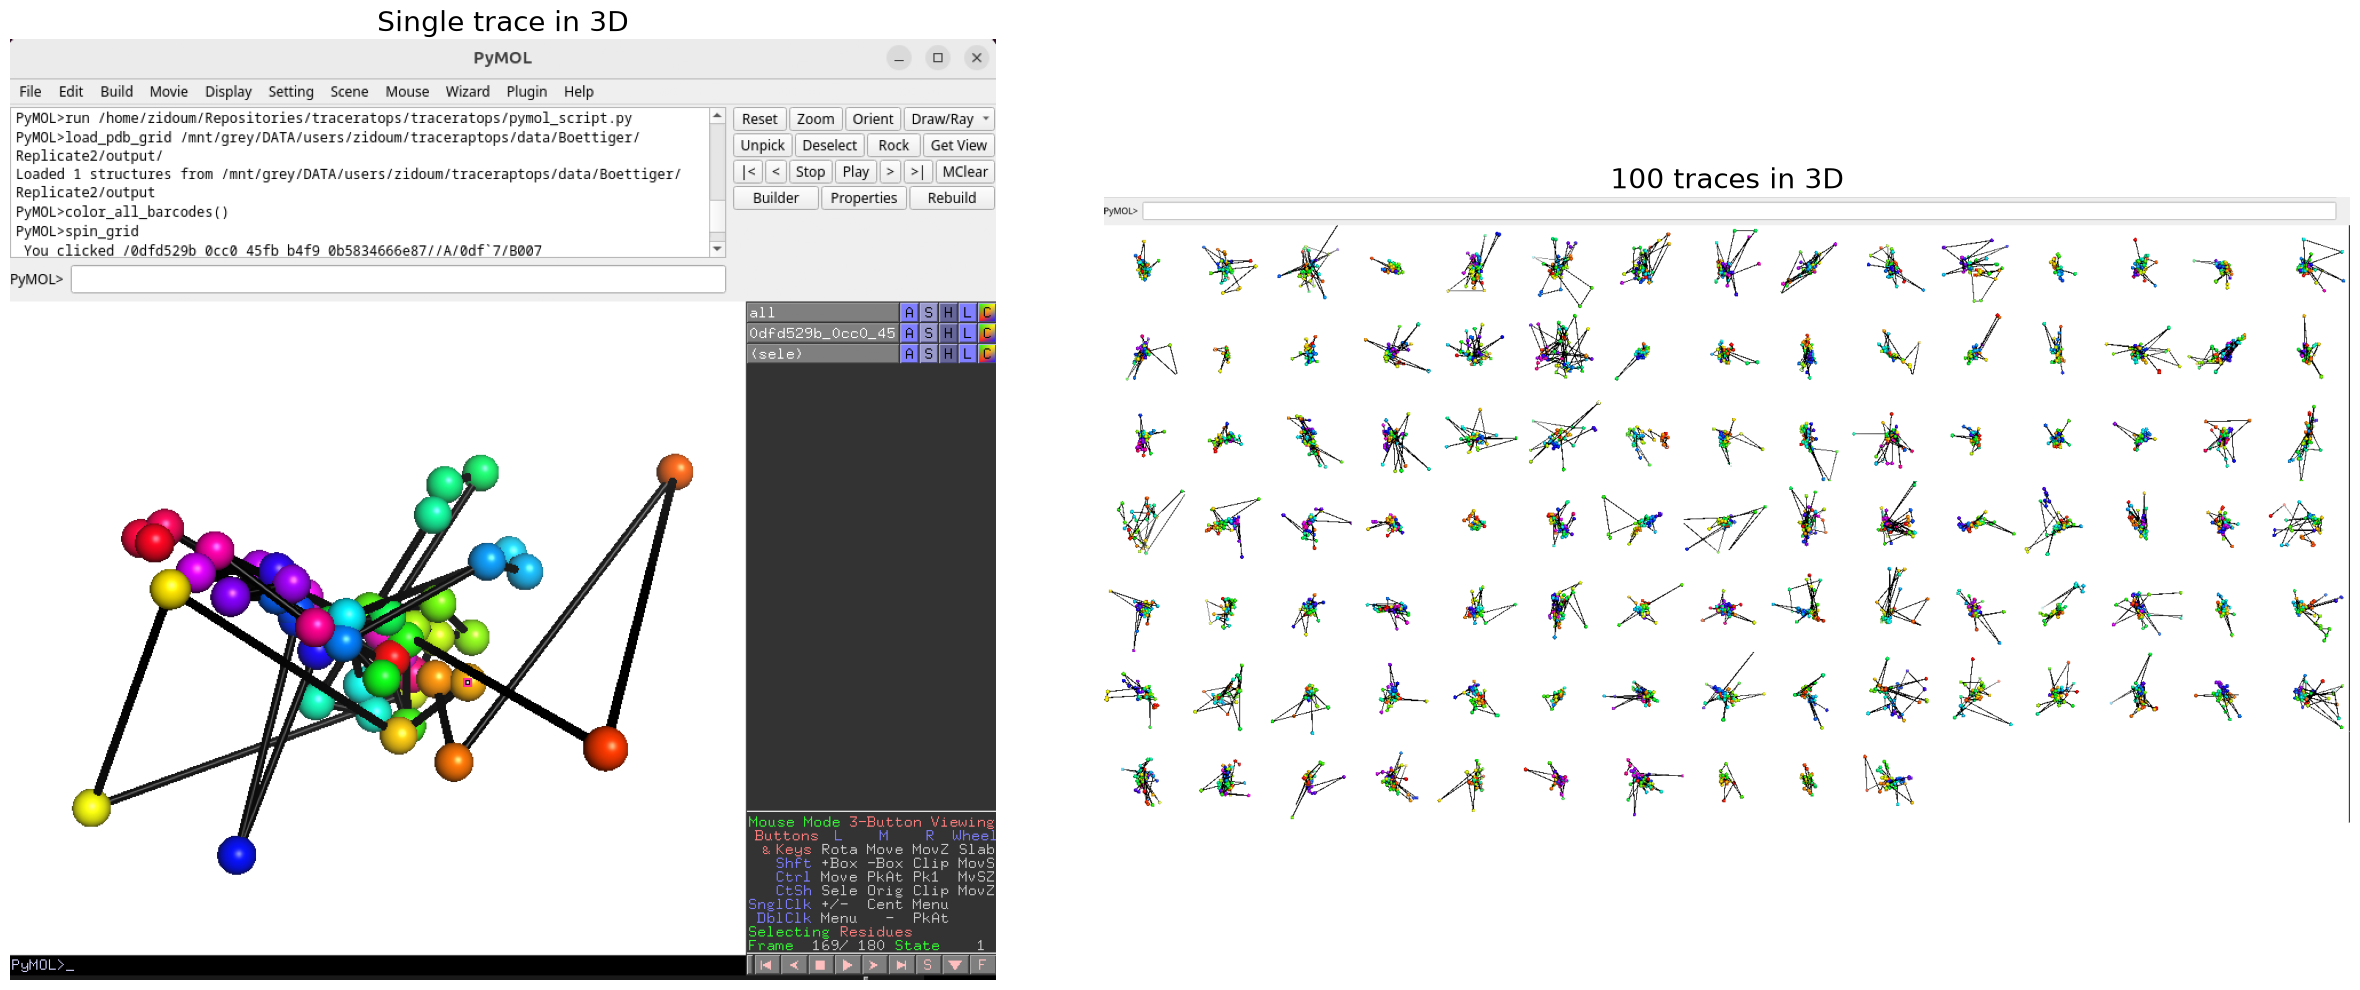

In [52]:
# Example of what you should be visualizing in pymol

screenchot2 = f"{dest_path}/pymol_structures.png"
screenshot3 = f"{dest_path}/pymol_100_strcutures.png"


fig, axes = plt.subplots(1, 2, figsize=(25, 10))

for ax, path,title in zip(axes, [screenshot2, screenshot3],["Single trace in 3D", "100 traces in 3D"]):
    ax.set_title(title, fontsize=20)
    img = mpimg.imread(path)
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Color code barcodes (atoms)
If the user provided a **json dictionary** (as seen above), these are used as ATOM names.
The json file has to be in the following format to link barcode identities with different ATOM names in the PDB file:

{"12": "C  ", "18": "N  ", "9": "P  "}

Keys provide barcode names in the trace file, these should be attributed to 3 character codes. In this example, the barcode 12 is assigned the ATOM name C, barcode 18 is assigned N and atom 9 is assigned P. This provides a useful way of colorcoding your barcodes using a user defined coloring code.

In this case you can run the first two lines of the script above (plot_traces and pymol terminal lines) and then apply separate colors for each barcode as follows as follows in the pymol terminal:

```
$ set grid_mode,1

$ color green,  (name C*)

$ color red, (name P*)

$ color yellow, (name N*) 
```

## Summary
## Visualize traces in pymol with `trace_plot`

| Option | Use |
|--------|-------------|
| -n | Number of traces used |
| -N | Minimum number of barcodes for traces selected |
| --selected_traces | Select traces for analysis |
| --all | Select all traces |
| --barcode_type_dict | Json dictionary linking barcodes and atom types (MUST BE 3 characters long!)|
| -O | Output tag  |


**Next:** [Pysical_vs_genomic_distances](docs/source/tutorials/tutorial_physical_vs_genomic_distances.ipynb)